# Dönem Projesi: İstanbul İlçelerinin Demografik Dönüşümü
**Proje Amacı:** TÜİK verileri kullanılarak İstanbul ilçelerinin yıllar içindeki nüfus, yaş ve cinsiyet dinamiklerinin incelenmesi ve ilçelerin demografik profillerine göre kümelenmesi.

In [1]:
# Gerekli kütüphanelerin tümü projeye en başta dahil edilir
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from IPython.display import display

# Grafiklerin genel estetik ayarları
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

## 1. Veri Yükleme ve Keşifsel İstatistikler
Veri seti yüklenir, temel boyutları, veri tipleri ve betimsel istatistikleri incelenir.

In [2]:
# Veri setini yükleyelim
df = pd.read_csv('veri_bilimi.csv')

# Verinin boyutunu ve sütunların veri tiplerini görelim
print("Veri Seti Bilgileri:")
df.info()

print("\n-----------------------------------\n")

# İlk 5 satırı görelim
print("İlk 5 Satır:")
display(df.head())

print("\n-----------------------------------\n")

# Temel istatistiksel özet (Sayısal sütunların ortalama, min, max değerleri)
print("Temel İstatistikler:")
display(df.describe())

Veri Seti Bilgileri:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 734 entries, 0 to 733
Data columns (total 42 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   _id             734 non-null    int64 
 1   Yil             734 non-null    int64 
 2   Ilce            734 non-null    object
 3   ilce_kodu       734 non-null    int64 
 4   Erkek ve 0-4    734 non-null    int64 
 5   Erkek ve 5-9    734 non-null    int64 
 6   Erkek ve 10-14  734 non-null    int64 
 7   Erkek ve 15-19  734 non-null    int64 
 8   Erkek ve 20-24  734 non-null    int64 
 9   Erkek ve 25-29  734 non-null    int64 
 10  Erkek ve 30-34  734 non-null    int64 
 11  Erkek ve 35-39  734 non-null    int64 
 12  Erkek ve 40-44  734 non-null    int64 
 13  Erkek ve 45-49  734 non-null    int64 
 14  Erkek ve 50-54  734 non-null    int64 
 15  Erkek ve 55-59  734 non-null    int64 
 16  Erkek ve 60-64  734 non-null    int64 
 17  Erkek ve 65-69  734 non-null    i

,_id,Yil,Ilce,ilce_kodu,Erkek ve 0-4,Erkek ve 5-9,Erkek ve 10-14,Erkek ve 15-19,Erkek ve 20-24,Erkek ve 25-29,...,Kadin ve 45-49,Kadin ve 50-54,Kadin ve 55-59,Kadin ve 60-64,Kadin ve 65-69,Kadin ve 70-74,Kadin ve 75-79,Kadin ve 80-84,Kadin ve 85-89,Kadin ve 90+
0,1,2007,Adalar,1103,236,293,314,395,576,473,...,382,367,287,277,208,193,137,123,43,36
1,2,2007,Avcılar,2003,12458,13222,13157,13647,13730,18458,...,10180,8647,6539,4205,3094,2384,1876,1219,473,421
2,3,2007,Bağcılar,2004,34607,37663,35723,34430,28730,41713,...,17379,14715,10468,6555,4626,3311,2897,1758,756,894
3,4,2007,Bahçelievler,2005,21638,23380,23962,24233,22535,31775,...,17609,15403,11253,7521,5781,4454,3595,2197,867,805
4,5,2007,Bakırköy,1166,4956,5151,5966,7118,9099,9155,...,8956,8399,6765,5417,4446,3861,3348,2428,926,549



-----------------------------------

Temel İstatistikler:


,_id,Yil,ilce_kodu,Erkek ve 0-4,Erkek ve 5-9,Erkek ve 10-14,Erkek ve 15-19,Erkek ve 20-24,Erkek ve 25-29,Erkek ve 30-34,...,Kadin ve 45-49,Kadin ve 50-54,Kadin ve 55-59,Kadin ve 60-64,Kadin ve 65-69,Kadin ve 70-74,Kadin ve 75-79,Kadin ve 80-84,Kadin ve 85-89,Kadin ve 90+
count,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,...,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000
mean,367.500000,2016.085831,1723.822888,13886.534060,14502.174387,14359.363760,14462.587193,14976.025886,17285.955041,17600.389646,...,12944.555858,10781.840599,8671.743869,6738.411444,5025.036785,3648.702997,2631.904632,1758.040872,940.602180,451.188011
std,212.031837,5.435670,323.085721,8903.809626,8964.209951,8549.627405,8152.285757,7640.249204,9499.681665,9744.265150,...,6818.638572,5638.415001,4563.209617,3754.696090,3025.363223,2376.190753,1837.310156,1343.127909,828.665674,469.480044
min,1.000000,2007.000000,1103.000000,222.000000,262.000000,266.000000,301.000000,576.000000,473.000000,422.000000,...,382.000000,367.000000,287.000000,277.000000,208.000000,193.000000,137.000000,112.000000,43.000000,20.000000
25%,184.250000,2011.000000,1421.000000,8177.250000,8850.750000,8900.500000,9281.500000,9924.500000,10984.250000,11403.750000,...,8456.000000,6995.500000,5770.750000,4198.250000,2984.750000,2119.000000,1458.500000,932.000000,431.250000,171.000000
50%,367.500000,2016.000000,1823.000000,12103.000000,13340.500000,13523.000000,13818.500000,13976.000000,15881.500000,15995.000000,...,11914.500000,9503.000000,7855.000000,6151.500000,4551.500000,3266.000000,2221.000000,1449.500000,735.000000,326.000000
75%,550.750000,2021.000000,2014.000000,17767.500000,18401.250000,18278.000000,18546.000000,19593.500000,22258.000000,22640.750000,...,17795.000000,14460.750000,11589.000000,8988.000000,6600.000000,4700.750000,3350.250000,2322.750000,1207.250000,553.750000
max,734.000000,2025.000000,2055.000000,48559.000000,52568.000000,50522.000000,47890.000000,40588.000000,56451.000000,51742.000000,...,35264.000000,27799.000000,23064.000000,19187.000000,16042.000000,14161.000000,12277.000000,9274.000000,5354.000000,3469.000000


## 2. Veri Temizleme ve Özellik Çıkarımı (Feature Engineering)
Analizde kullanılmayacak değişkenler çıkarılmış, Türkçe karakter sorunları giderilmiş ve analizlerde kolaylık sağlaması adına alt kırılımlar toplanarak `toplam_nufus`, `toplam_erkek`, `toplam_kadin` gibi yeni özet sütunlar oluşturulmuştur.

In [3]:
print("Veri Temizleme ve Dönüştürme Başlıyor...")

# 1. Analizde işimize yaramayacak '_id' ve 'ilce_kodu' sütunlarını düşürüyoruz
df_cleaned = df.drop(columns=['_id', 'ilce_kodu'])

# 2. Sütun isimlerini programatik olarak temizliyoruz
def sutun_ismi_temizle(isim):
    isim = isim.lower() # Tüm harfleri küçült
    isim = isim.replace(' ve ', '_') # ' ve ' kelimesini alt tire yap
    isim = isim.replace('-', '_') # Tireleri alt tire yap
    isim = isim.replace('+', '_arti') # 90+ gibi durumlar için artı yaz
    isim = isim.replace(' ', '_') # Kalan boşlukları alt tire yap
    isim = isim.replace('ı', 'i').replace('ç', 'c').replace('ş', 's').replace('ğ', 'g').replace('ü', 'u').replace('ö', 'o')
    return isim

df_cleaned.columns = [sutun_ismi_temizle(col) for col in df_cleaned.columns]

# 3. Özellik Çıkarımı: Toplam Nüfus Sütunları
erkek_sutunlari = [col for col in df_cleaned.columns if 'erkek' in col]
df_cleaned['toplam_erkek'] = df_cleaned[erkek_sutunlari].sum(axis=1)

kadin_sutunlari = [col for col in df_cleaned.columns if 'kadin' in col]
df_cleaned['toplam_kadin'] = df_cleaned[kadin_sutunlari].sum(axis=1)

df_cleaned['toplam_nufus'] = df_cleaned['toplam_erkek'] + df_cleaned['toplam_kadin']

# 4. Eksik Veri (NaN) ve Aykırı Değer Kontrolü
print("Toplam eksik hücre sayısı:", df_cleaned.isnull().sum().sum())

# Kısmi Aykırı Değer (Outlier) Tespiti: Nüfusu 0 olan hatalı ilçe kaydı var mı?
aykiri_kayitlar = df_cleaned[df_cleaned['toplam_nufus'] <= 0]
if not aykiri_kayitlar.empty:
    print("Uyarı: Nüfusu 0 veya daha az olan hatalı kayıtlar bulundu.")
else:
    print("Aykırı değer kontrolü: 0 nüfuslu ilçe kaydı bulunamadı (Veri mantıklı).")

display(df_cleaned.head())

Veri Temizleme ve Dönüştürme Başlıyor...
Toplam eksik hücre sayısı: 0
Aykırı değer kontrolü: 0 nüfuslu ilçe kaydı bulunamadı (Veri mantıklı).


,yil,ilce,erkek_0_4,erkek_5_9,erkek_10_14,erkek_15_19,erkek_20_24,erkek_25_29,erkek_30_34,erkek_35_39,...,kadin_60_64,kadin_65_69,kadin_70_74,kadin_75_79,kadin_80_84,kadin_85_89,kadin_90_arti,toplam_erkek,toplam_kadin,toplam_nufus
0,2007,Adalar,236,293,314,395,576,473,422,406,...,277,208,193,137,123,43,36,5412,5048,10460
1,2007,Avcılar,12458,13222,13157,13647,13730,18458,16318,13275,...,4205,3094,2384,1876,1219,473,421,162132,161464,323596
2,2007,Bağcılar,34607,37663,35723,34430,28730,41713,36585,29782,...,6555,4626,3311,2897,1758,756,894,364380,354887,719267
3,2007,Bahçelievler,21638,23380,23962,24233,22535,31775,28338,23765,...,7521,5781,4454,3595,2197,867,805,283805,287906,571711
4,2007,Bakırköy,4956,5151,5966,7118,9099,9155,8223,7642,...,5417,4446,3861,3348,2428,926,549,102465,112356,214821


## 3. Keşifsel Veri Analizi (EDA)

### Araştırma Sorusu 1: Nüfus Dinamikleri
2007'den günümüze İstanbul nüfusunun genel trendi nasıldır ve hangi ilçeler oransal olarak en çok büyümüş/küçülmüştür?

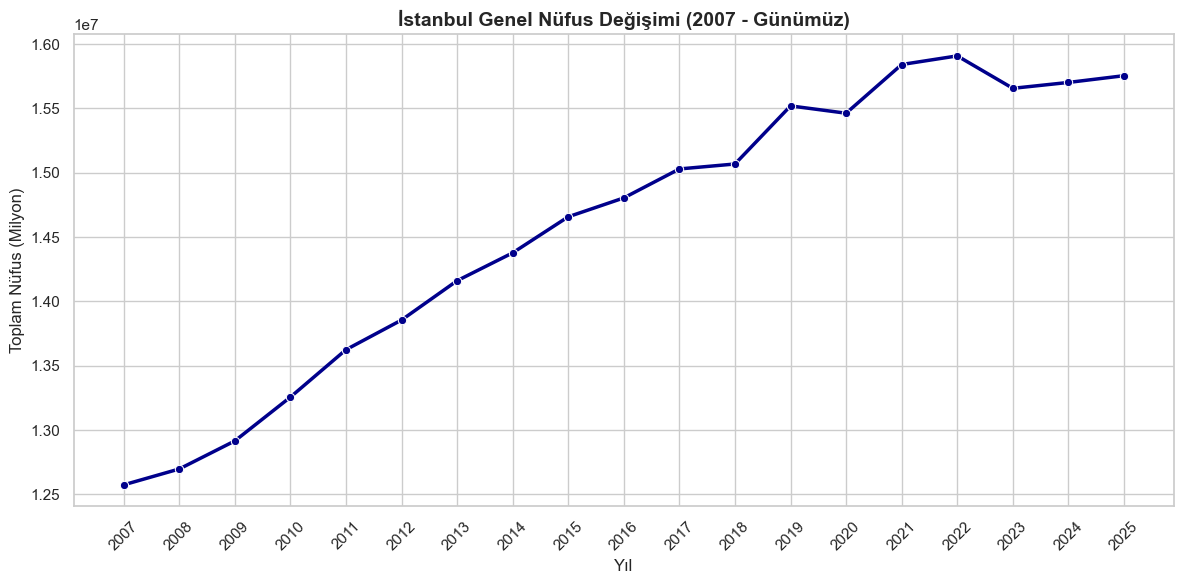

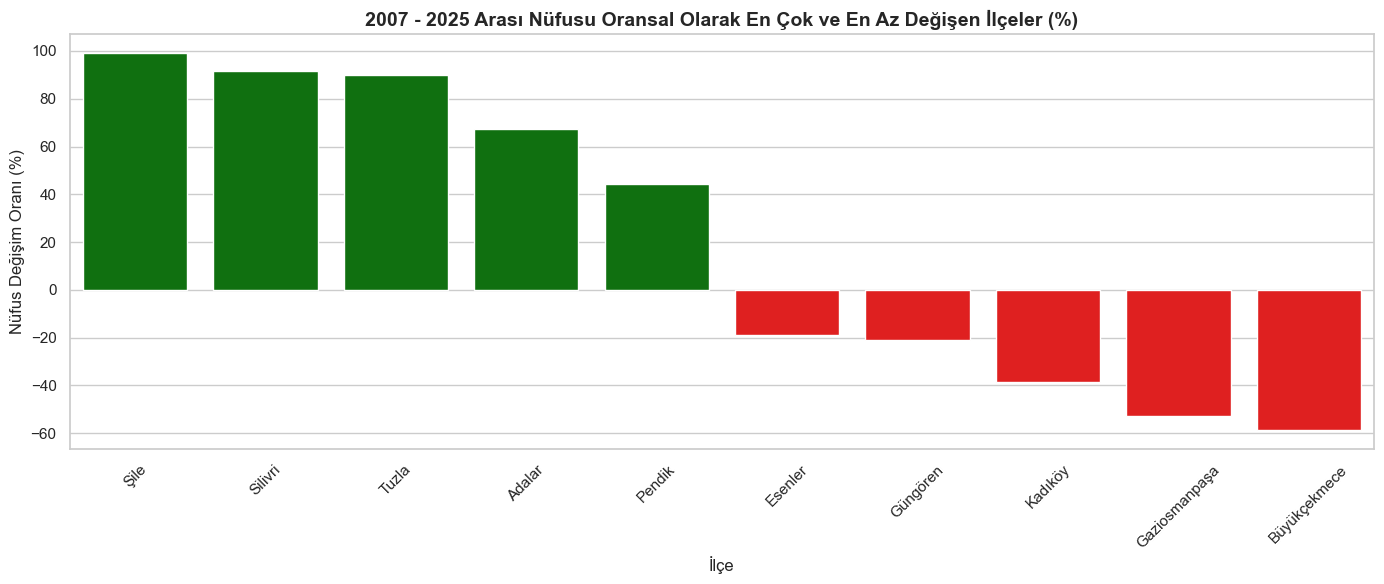

In [4]:
# --- 1. KISIM: İstanbul Genel Nüfus Trendi (Line Chart) ---
istanbul_genel = df_cleaned.groupby('yil')['toplam_nufus'].sum().reset_index()

plt.figure()
sns.lineplot(data=istanbul_genel, x='yil', y='toplam_nufus', marker='o', linewidth=2.5, color='darkblue')
plt.title('İstanbul Genel Nüfus Değişimi (2007 - Günümüz)', fontsize=14, fontweight='bold')
plt.xlabel('Yıl', fontsize=12)
plt.ylabel('Toplam Nüfus (Milyon)', fontsize=12)
plt.xticks(istanbul_genel['yil'].unique(), rotation=45)
plt.tight_layout()
plt.show()

# --- 2. KISIM: İlçe Bazlı Oransal Büyüme (Bar Chart) ---
ilk_yil = df_cleaned['yil'].min()
son_yil = df_cleaned['yil'].max()

df_ilk = df_cleaned[df_cleaned['yil'] == ilk_yil][['ilce', 'toplam_nufus']].rename(columns={'toplam_nufus': 'nufus_2007'})
df_son = df_cleaned[df_cleaned['yil'] == son_yil][['ilce', 'toplam_nufus']].rename(columns={'toplam_nufus': 'nufus_son'})

df_growth = pd.merge(df_ilk, df_son, on='ilce')
df_growth['buyume_orani_%'] = ((df_growth['nufus_son'] - df_growth['nufus_2007']) / df_growth['nufus_2007']) * 100

en_cok_buyuyen = df_growth.sort_values(by='buyume_orani_%', ascending=False).head(5)
en_az_buyuyen = df_growth.sort_values(by='buyume_orani_%', ascending=True).head(5)
df_top_bottom = pd.concat([en_cok_buyuyen, en_az_buyuyen]).sort_values(by='buyume_orani_%', ascending=False)

plt.figure(figsize=(14, 6))
colors = ['green' if x > 0 else 'red' for x in df_top_bottom['buyume_orani_%']]
sns.barplot(data=df_top_bottom, x='ilce', y='buyume_orani_%', hue='ilce', palette=colors, legend=False)
plt.title(f'2007 - {son_yil} Arası Nüfusu Oransal Olarak En Çok ve En Az Değişen İlçeler (%)', fontsize=14, fontweight='bold')
plt.xlabel('İlçe', fontsize=12)
plt.ylabel('Nüfus Değişim Oranı (%)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Araştırma Sorusu 2: Demografik Dönüşüm ve Yaşlanma
İstanbul ilçeleri yaşlanıyor mu? 65 yaş ve üstü nüfus oranının en yüksek ve en düşük olduğu ilçeler hangileridir?

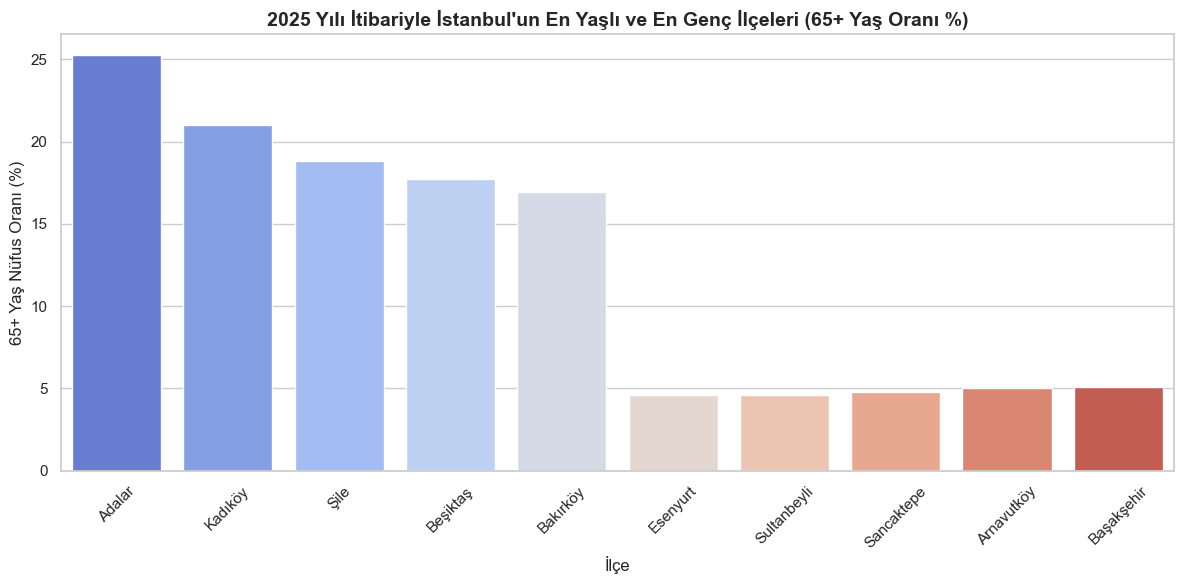

In [5]:
yas_65_ustu_sutunlar = [col for col in df_cleaned.columns if any(yas in col for yas in ['65_69', '70_74', '75_79', '80_84', '85_89', '90_arti'])]
df_cleaned['toplam_65_ustu'] = df_cleaned[yas_65_ustu_sutunlar].sum(axis=1)
df_cleaned['yasli_nufus_orani_%'] = (df_cleaned['toplam_65_ustu'] / df_cleaned['toplam_nufus']) * 100

df_en_son = df_cleaned[df_cleaned['yil'] == son_yil]
en_yasli_ilceler = df_en_son.sort_values(by='yasli_nufus_orani_%', ascending=False).head(5)
en_genc_ilceler = df_en_son.sort_values(by='yasli_nufus_orani_%', ascending=True).head(5)
df_age_comparison = pd.concat([en_yasli_ilceler, en_genc_ilceler])

plt.figure(figsize=(12, 6))
sns.barplot(data=df_age_comparison, x='ilce', y='yasli_nufus_orani_%', hue='ilce', palette='coolwarm', legend=False)
plt.title(f'{son_yil} Yılı İtibariyle İstanbul\'un En Yaşlı ve En Genç İlçeleri (65+ Yaş Oranı %)', fontsize=14, fontweight='bold')
plt.xlabel('İlçe', fontsize=12)
plt.ylabel('65+ Yaş Nüfus Oranı (%)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Araştırma Sorusu 3: Cinsiyet Dengesizlikleri
Normal şartlarda 1.0 (Erkek=Kadın) olması beklenen cinsiyet rasyosunun en çok saptığı ilçeler hangileridir?

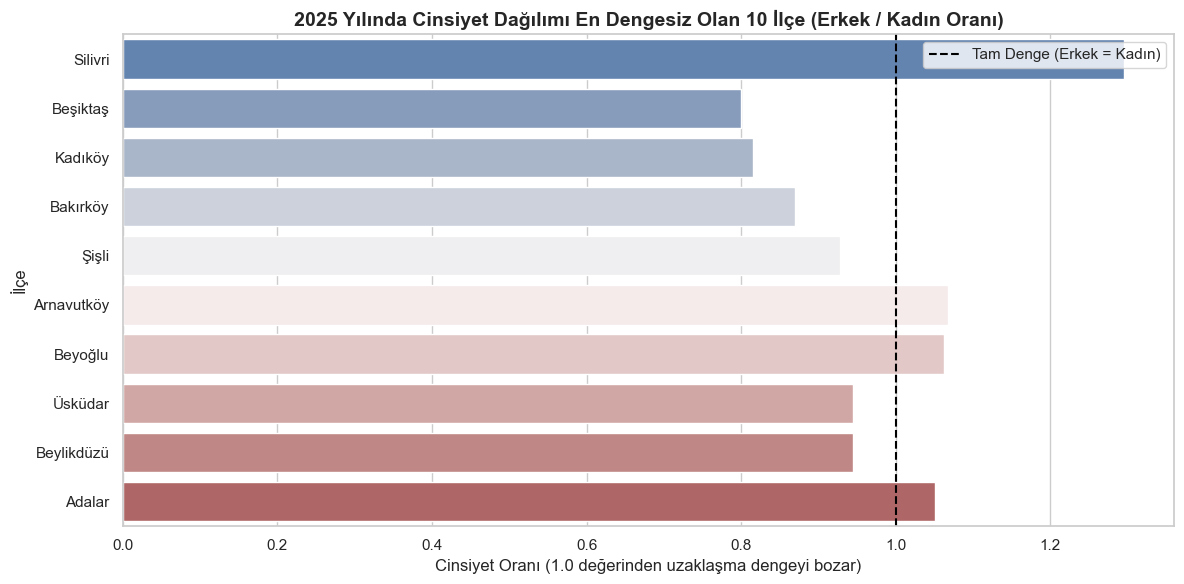

In [6]:
df_gender = df_cleaned[df_cleaned['yil'] == son_yil].copy()
df_gender['cinsiyet_orani_erkek_kadin'] = df_gender['toplam_erkek'] / df_gender['toplam_kadin']
df_gender['dengeden_sapma'] = (df_gender['cinsiyet_orani_erkek_kadin'] - 1.0).abs()

dengesiz_ilceler = df_gender.sort_values(by='dengeden_sapma', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=dengesiz_ilceler, x='cinsiyet_orani_erkek_kadin', y='ilce', hue='ilce', palette='vlag', legend=False)
plt.axvline(x=1.0, color='black', linestyle='--', linewidth=1.5, label='Tam Denge (Erkek = Kadın)')
plt.title(f'{son_yil} Yılında Cinsiyet Dağılımı En Dengesiz Olan 10 İlçe (Erkek / Kadın Oranı)', fontsize=14, fontweight='bold')
plt.xlabel('Cinsiyet Oranı (1.0 değerinden uzaklaşma dengeyi bozar)', fontsize=12)
plt.ylabel('İlçe', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

## 4. Modelleme: K-Means ile İlçe Profili Kümeleme
İlçeler, yaş piramitlerindeki çocuk (0-14), üretken (15-64) ve yaşlı (65+) nüfus oranlarına göre K-Means algoritması ile makine öğrenmesine tabi tutulmuş ve 3 temel demografik profile ayrılmıştır.

Küme Profilleri (Yaş Gruplarının Küme Bazlı Ortalama Yüzdeleri %):


,oran_0_14,oran_15_64,oran_65_ustu
kume,,,
0,20.374150,60.486909,19.138941
1,24.587247,65.371815,10.040937
2,30.338963,63.347391,6.313646


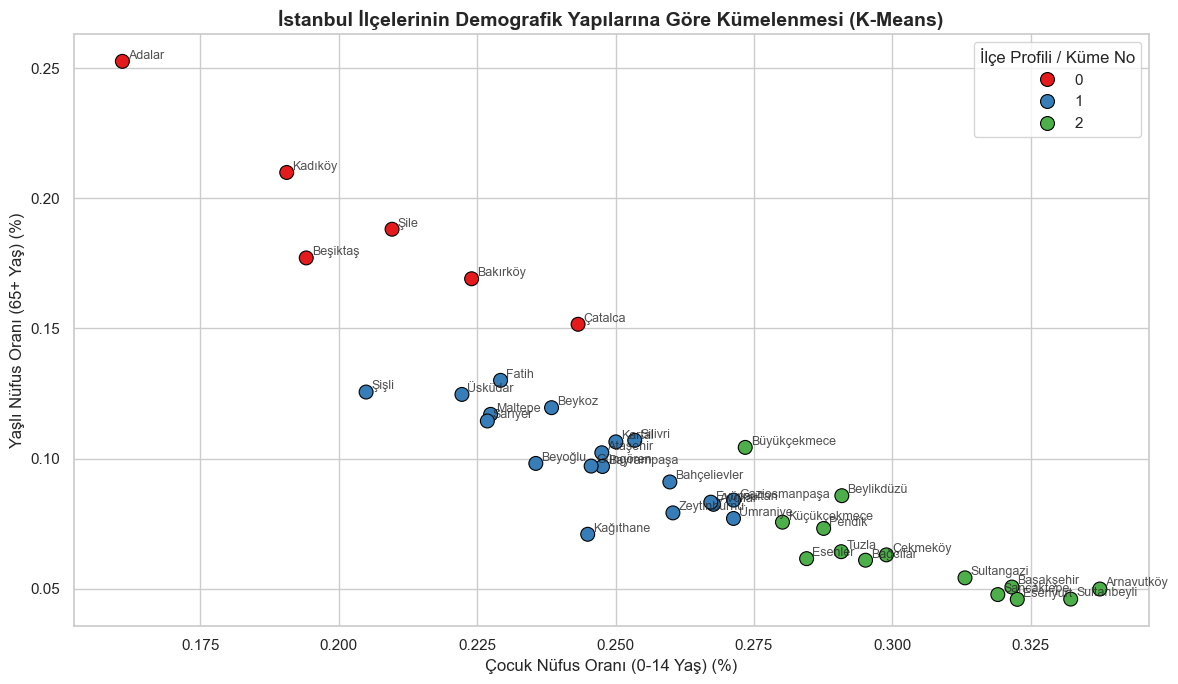

In [7]:
# 1. Adım: Yaş Gruplarını Tanımlama
çocuk_sutunları = [col for col in df_cleaned.columns if any(age in col for age in ['0_4', '5_9', '10_14'])]
yasli_sutunlari = yas_65_ustu_sutunlar 

df_model = df_cleaned[df_cleaned['yil'] == son_yil].copy()
df_model['oran_0_14'] = df_model[çocuk_sutunları].sum(axis=1) / df_model['toplam_nufus']
df_model['oran_65_ustu'] = df_model[yasli_sutunlari].sum(axis=1) / df_model['toplam_nufus']
df_model['oran_15_64'] = 1.0 - (df_model['oran_0_14'] + df_model['oran_65_ustu'])

X_features = ['oran_0_14', 'oran_15_64', 'oran_65_ustu']

# 2. Adım: Standardizasyon 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model[X_features])

# 3. Adım: K-Means Modelinin Eğitilmesi
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_model['kume'] = kmeans.fit_predict(X_scaled)

# 4. Adım: Kümelerin Karakteristik Özelliklerini Görme 
kume_profilleri = df_model.groupby('kume')[X_features].mean() * 100
print("Küme Profilleri (Yaş Gruplarının Küme Bazlı Ortalama Yüzdeleri %):")
display(kume_profilleri)

# 5. Adım: Görselleştirme (Scatter Plot)
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df_model, 
    x='oran_0_14', 
    y='oran_65_ustu', 
    hue='kume', 
    palette='Set1', 
    s=100, 
    edgecolor='black'
)

# Grafik üzerine ilçe isimlerini yazdıralım
for i in range(df_model.shape[0]):
    plt.text(
        x=df_model['oran_0_14'].iloc[i] + 0.001, 
        y=df_model['oran_65_ustu'].iloc[i] + 0.001, 
        s=df_model['ilce'].iloc[i], 
        fontsize=9, 
        alpha=0.8
    )

plt.title('İstanbul İlçelerinin Demografik Yapılarına Göre Kümelenmesi (K-Means)', fontsize=14, fontweight='bold')
plt.xlabel('Çocuk Nüfus Oranı (0-14 Yaş) (%)', fontsize=12)
plt.ylabel('Yaşlı Nüfus Oranı (65+ Yaş) (%)', fontsize=12)
plt.legend(title='İlçe Profili / Küme No')
plt.tight_layout()
plt.show()